In [1]:
import math
import numpy as np
from numpy import linalg as LA
import quantecon as qe
import matplotlib.pyplot as plt

import random
random.seed(1234)

### part b

In [2]:
a = 0.04
b = 0.16
K = 0.1

p_n = [K*np.exp(a*i) for i in range (1,5)]  # p(n,n+1)
q_n = [K*np.exp(b*(i-1)) for i in range (2,6)]  # p(n,n-1)

p_n.append(0)   # p(5,1) = 1
q_n.insert(0,0) # q(1,5) = 0

# p_nn = [1 - K*np.exp(a*n) - K*np.exp(b*(n-1)) for n in range(1,6)]   # p(n,n) = 1 - p_n - q_n
p_nn = []

for n in range(1,6):
    if n == 1:
        p_nn.append(1 - K*np.exp(a*n))
    elif n < 5:
        p_nn.append(1 - K*np.exp(a*n) - K*np.exp(b*(n-1)))
    else:
        p_nn.append(1 - K*np.exp(b*(n-1)))

In [3]:
# construct probability transition matrix
p = []

for i in range(0,5):
    r = []
    for j in range(0,5):
        if j == i-1:
            r.append(q_n[j+1])    # p(n,n-1)
        elif j == i:
            r.append(p_nn[j]) # diagonal entry of p
        elif j == i+1:
            r.append(p_n[j-1])    # p(n,n+1)
        else:
            r.append(0)
    p.append(r)

print("The probability transition matrix is:\n\n", np.round(np.array(p),4))

The probability transition matrix is:

 [[0.8959 0.1041 0.     0.     0.    ]
 [0.1174 0.7743 0.1083 0.     0.    ]
 [0.     0.1377 0.7495 0.1127 0.    ]
 [0.     0.     0.1616 0.721  0.1174]
 [0.     0.     0.     0.1896 0.8104]]


In [21]:
p_t = np.transpose(p)
print(f"p-transpose is:\n\n {p_t}\n")

eigenvalues, eigenvectors = LA.eig(p_t)
eigenvalues = np.ma.round(eigenvalues, 4)

sd = np.ma.round(eigenvectors[:,np.where(eigenvalues == 1)], 4)

# renormalize sd in correct norm
normalization = 0.6201+0.5499+0.4326+0.3018+0.1868
sd_new = sd/normalization
print(f"\nThe normalized stationary distribution is:\n\n{np.round(sd_new,4)}")


p-transpose is:

 [[0.89591892 0.11735109 0.         0.         0.        ]
 [0.10408108 0.77432021 0.13771278 0.         0.        ]
 [0.         0.10832871 0.74953754 0.16160744 0.        ]
 [0.         0.         0.11274969 0.72104147 0.18964809]
 [0.         0.         0.         0.11735109 0.81035191]]


The normalized stationary distribution is:

[[[0.2965]]

 [[0.263 ]]

 [[0.2069]]

 [[0.1443]]

 [[0.0893]]]


### part c

In [6]:
# generate a Markov Chain from probability transition matrix p
# mc = qe.MarkovChain(p, state_values = ("1", "2", "3", "4", "5"))
mc = qe.MarkovChain(p, state_values = (1, 2, 3, 4, 5))

steps = np.int64(1E6)     # steps in MC

# simluate Markov-chain for [steps] steps
x_mc = mc.simulate(ts_length = steps)

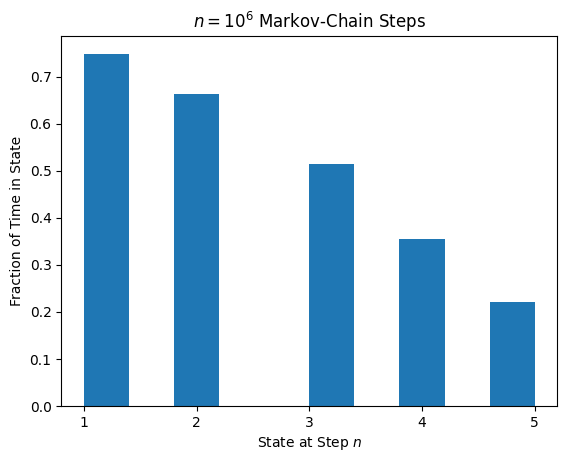

In [8]:
# plot MC results
plt.hist(x_mc, density = True, align='mid', range = (1,5))
plt.title("$n=10^6$ Markov-Chain Steps")
plt.xticks(np.arange(min(x_mc), max(x_mc)+1, 1.0))
plt.xlabel("State at Step $n$")
plt.ylabel("Fraction of Time in State")
plt.show()

### part d

<>:19: SyntaxWarning: invalid escape sequence '\p'
<>:19: SyntaxWarning: invalid escape sequence '\p'
C:\Users\taylo\AppData\Local\Temp\ipykernel_12280\1663382610.py:19: SyntaxWarning: invalid escape sequence '\p'
  plt.title("$n=10^6$ Markov-Chain Steps from Theoretical $\pi$")


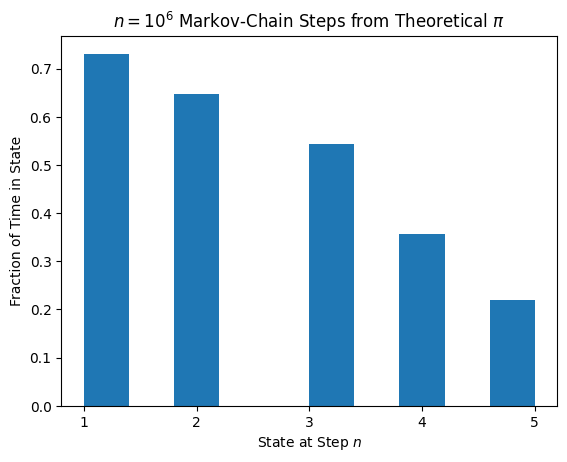

In [52]:
# theoretical SD results

pi_theory = np.array([
    1/(1 + np.exp(6*(a-b)) + np.exp(3*(a-b)) + np.exp(1*(a-b)) + np.exp(10*(a-b))),                 # pi(1)
    1/(1 + np.exp(9*(a-b)) + np.exp(5*(a-b)) + np.exp(2*(a-b)) + np.exp(-1*(a-b))),                 # pi(2)
    1/(1 + np.exp(7*(a-b)) + np.exp(3*(a-b)) + np.exp(-2*(a-b)) + np.exp(-1*(a-b))),                # pi(3)
    1/(1 + np.exp(4*(a-b)) + np.exp(-3*(a-b)) + np.exp(-5*(a-b)) + np.exp(-6*(a-b))),               # pi(4)
    1/(1 + np.exp((-10*a)+(4*b))*(np.exp(6*a) + np.exp(6*b) + np.exp(3*(a+b)) + np.exp(a+(5*b))))   # pi(5)
])

x_sd_theory = []

for i in range(0,5):
    state = [i+1]*np.int64(np.round(steps*pi_theory[i],0))
    x_sd_theory = x_sd_theory + state

# plot theoretical SD results
plt.hist(x_sd_theory, density = True, align='mid', range = (1,5))
plt.title("$n=10^6$ Markov-Chain Steps from Theoretical $\pi$")
plt.xticks(np.arange(min(x_sd_theory), max(x_sd_theory)+1, 1.0))
plt.xlabel("State at Step $n$")
plt.ylabel("Fraction of Time in State")
plt.show()

<>:12: SyntaxWarning: invalid escape sequence '\p'
<>:12: SyntaxWarning: invalid escape sequence '\p'
C:\Users\taylo\AppData\Local\Temp\ipykernel_12280\2833063078.py:12: SyntaxWarning: invalid escape sequence '\p'
  plt.title("$n=10^6$ Markov-Chain Steps from Numerical $\pi$")


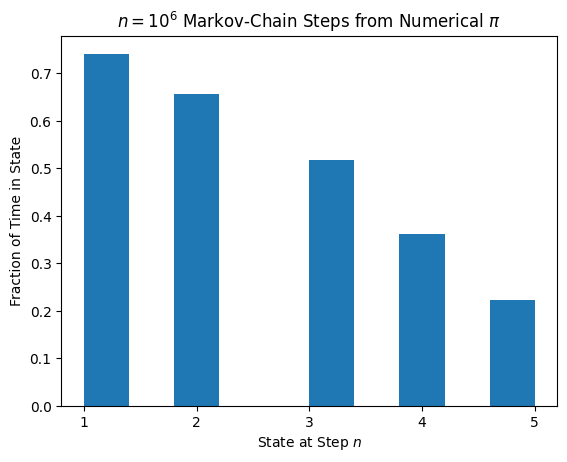

In [50]:
# numerical SD results
x_sd_numeric = []

for i in range(0,5):
    state = [i+1]*np.int64(np.round(steps*sd_new[i][0][0],0))
    # print(f"{i+1}s: {np.int64(steps*pi[0][0])}")
    # tot += len(test_i)
    x_sd_numeric = x_sd_numeric + state

# plot numerical SD results
plt.hist(x_sd_numeric, density = True, align='mid', range = (1,5))
plt.title("$n=10^6$ Markov-Chain Steps from Numerical $\pi$")
plt.xticks(np.arange(min(x_sd_numeric), max(x_sd_numeric)+1, 1.0))
plt.xlabel("State at Step $n$")
plt.ylabel("Fraction of Time in State")
plt.show()

In [65]:
def rand_num():
    num = random.random()
    if num != 0:
        return num
   
lamb_2 = lambda a : np.sqrt(1 - 3*a + 3*a**2)

a_lst = [lamb_2(rand_num()) for i in range(0,1000000)]

test = [x for x in a_lst if x == 1]

test
# print(lambda_2)
# print(rand_num())

[]

In [68]:
i = 100
a = 0.01**i 
b = 0.25**i
c = 0.5**i

print(a,b,c)

1.000000000000002e-200 6.223015277861142e-61 7.888609052210118e-31
